Title: ERA5_SMARD_Comparison.ipynb

Purpose: 

Author: Onno Nennecke on 29.04.2025 Modified: 29.04.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob
import seaborn as sns
from scipy.stats import pearsonr

# Importing custom functions
import Functions.demand as demand

In [133]:
# path = '/climca/people/onennecke/model_output/'
# file = 'ERA5_timeseries.nc'
# full_path = sorted(glob.glob(os.path.join(path, file)))

In [134]:
ERA5_dataset = xr.open_dataset('/climca/people/onennecke/model_output/ERA5_timeseries_cor.nc')
ERA5_dataset_weekly_averaged = xr.open_dataset('/climca/people/onennecke/model_output/ERA5_timeseries.nc')

# Cut to the same time period as SMARD data (2015-2023)
ERA5_dataset_15_23 = ERA5_dataset.sel(time=slice('2015-01-01', '2023-12-31'))
ERA5_dataset_15_23.load()

ERA5_dataset_weekly_averaged_15_23 = ERA5_dataset_weekly_averaged.sel(time=slice('2015-01-01', '2023-12-31'))

### Load SMARD data

In [135]:
SMARD_data_prod = pd.read_csv('/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')
SMARD_data_demand = pd.read_csv('/home/onennecke/SMARD_data/Realisierter_Stromverbrauch_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')

In [161]:

date = pd.to_datetime(SMARD_data_prod['Datum von'].astype(str).str.zfill(8), format='%d%m%Y')
demand = SMARD_data_demand['Netzlast [MWh] Berechnete Auflösungen']
wind_off_prod = SMARD_data_prod['Wind Offshore [MWh] Berechnete Auflösungen']
wind_on_prod = SMARD_data_prod['Wind Onshore [MWh] Berechnete Auflösungen']
solar_prod = SMARD_data_prod['Photovoltaik [MWh] Berechnete Auflösungen']
total_prod = wind_off_prod + wind_on_prod + solar_prod

df = pd.DataFrame({
    'date': date,
    'demand_SMARD': demand / 1000,  # Convert to GWh
    'wind_offshore_SMARD': wind_off_prod / 1000,  # Convert to GWh
    'wind_onshore_SMARD': wind_on_prod / 1000,  # Convert to GWh
    'solar_SMARD': solar_prod / 1000,  # Convert to GWh
    'total_production_SMARD': total_prod / 1000  # Convert to GWh
})


In [162]:
# Cut data to the same time period as ERA5 data (2015-2023)
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2023-12-31')]
df

,date,demand_SMARD,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,total_production_SMARD
0,2015-01-01,1096.85275,12.50850,298.79175,17.08025,328.38050
1,2015-01-02,1288.91475,10.32925,591.62075,7.75900,609.70900
2,2015-01-03,1213.30950,12.11950,457.04350,7.23475,476.39775
3,2015-01-04,1177.89600,11.53850,379.02950,19.98250,410.55050
4,2015-01-05,1425.92750,7.74550,219.62350,26.52225,253.89125
...,...,...,...,...,...,...
3282,2023-12-27,1157.06250,97.25750,411.66925,50.74875,559.67550
3283,2023-12-28,1204.96625,125.05950,895.99000,31.72925,1052.77875
3284,2023-12-29,1186.49150,130.81075,932.31525,30.03100,1093.15700
3285,2023-12-30,1104.32975,135.19125,638.87125,46.20325,820.26575


### Combine both datasets

In [163]:
df['temp_ERA5'] = ERA5_dataset_15_23['temp'].values
df['demand_ERA5'] = ERA5_dataset_15_23['demand'].values
df['demand_ERA5_weekly'] = ERA5_dataset_weekly_averaged_15_23['demand'].values
df['wind_offshore_ERA5'] = ERA5_dataset_15_23['wind_off_prod'].values
df['wind_onshore_ERA5'] = ERA5_dataset_15_23['wind_on_prod'].values
df['solar_ERA5'] = ERA5_dataset_15_23['solar_prod'].values
df['total_production_ERA5'] = df['wind_offshore_ERA5'] + df['wind_onshore_ERA5'] + df['solar_ERA5']
df['total_production_ERA5_check'] = ERA5_dataset_15_23['total_prod'].values

In [164]:
# Add weekday or weekend
df['weekday'] = df['date'].dt.dayofweek + 1
df['period'] = np.where(df['weekday'] <= 5, 'weekday', 'weekend')



In [188]:
# Define national fixed-date holidays (month, day)
fixed_holidays = [
    (1, 1),   # New Year's Day
    (5, 1),   # Labor Day
    (10, 3),  # German Unity Day
]

# Start by setting all to 'other'
df['special'] = df['period'].copy()

# Summer
df.loc[(df['date'].dt.month == 7) & (df['date'].dt.day >= 15), 'special'] = 'summer'
df.loc[(df['date'].dt.month == 8) & (df['date'].dt.day <= 15), 'special'] = 'summer'


# Christmas period (Dec 20–31)
df.loc[(df['date'].dt.month == 12) & (df['date'].dt.day >= 23), 'special'] = 'christmas'

# Fixed-date holidays
is_fixed_holiday = df['date'].dt.month.astype(str).str.zfill(2) + '-' + df['date'].dt.day.astype(str).str.zfill(2)
fixed_strs = [f"{m:02d}-{d:02d}" for m, d in fixed_holidays]
df.loc[is_fixed_holiday.isin(fixed_strs), 'special'] = 'holiday'


### Make plots to compare the datasets

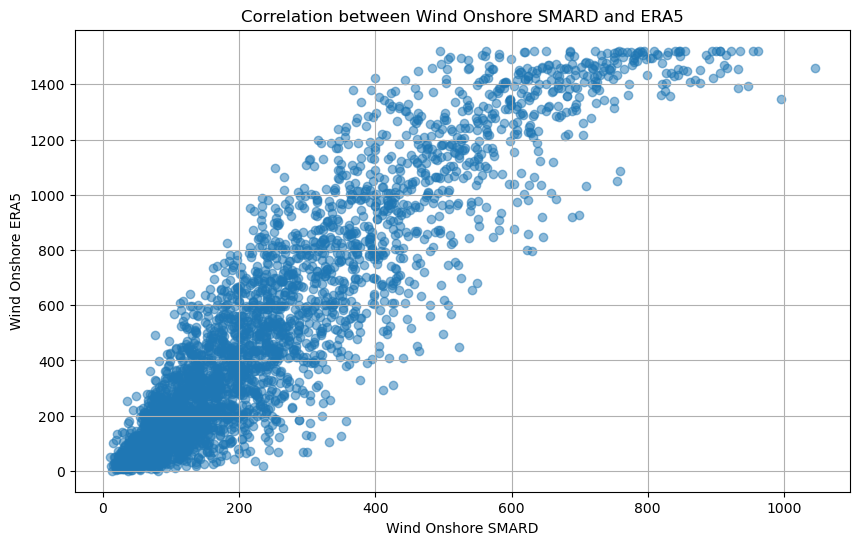

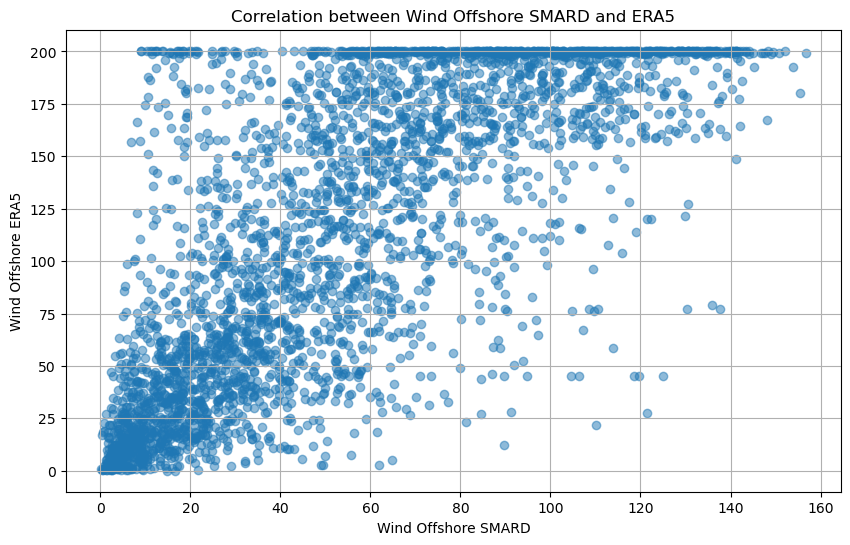

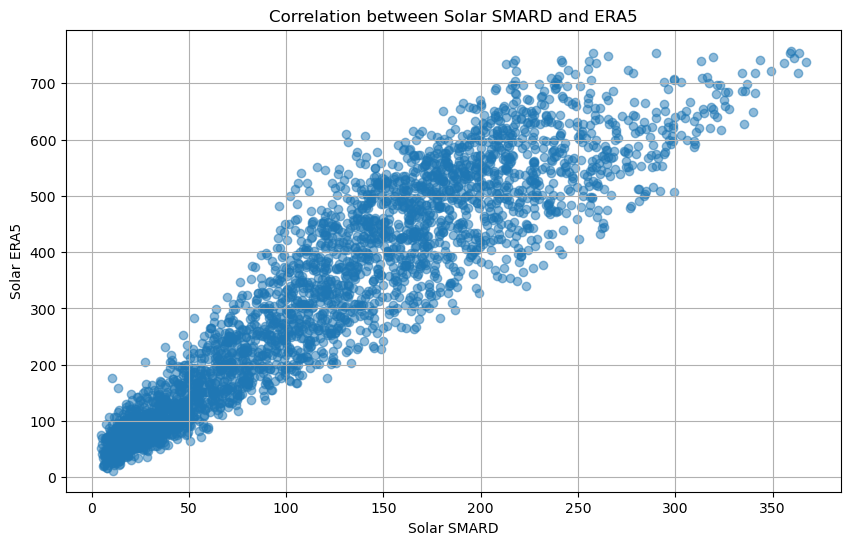

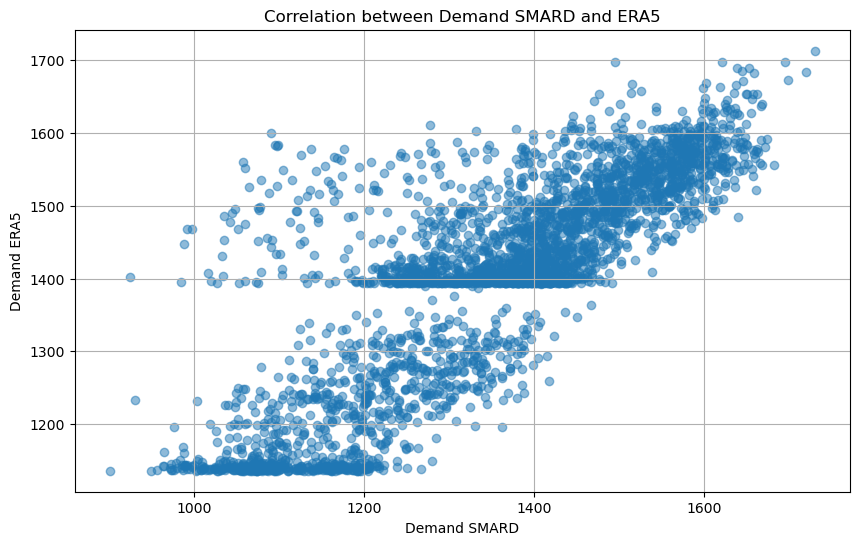

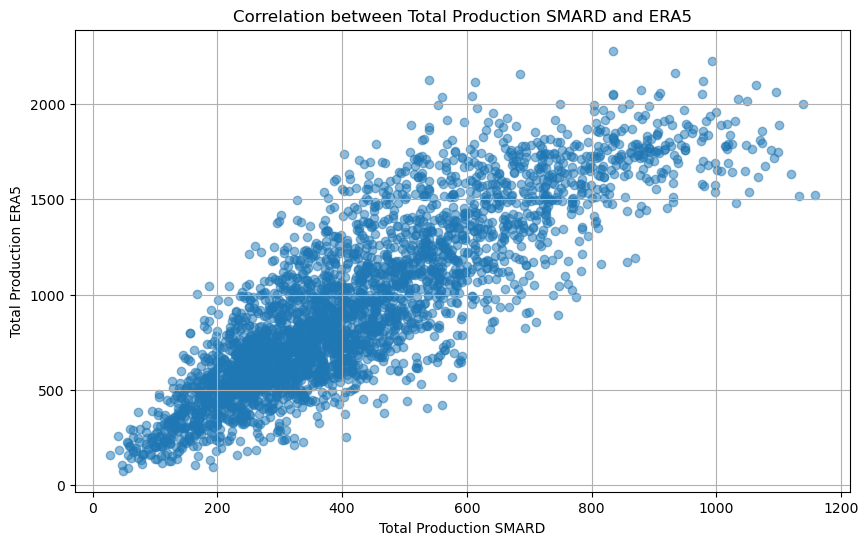

In [140]:
# 5 Correlation plots for wind onshore, wind offshore, solar, demand and total production
def plot_correlation(x, y, x_label, y_label, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid()
    plt.show()
plot_correlation(df['wind_onshore_SMARD'], df['wind_onshore_ERA5'], 'Wind Onshore SMARD', 'Wind Onshore ERA5', 'Correlation between Wind Onshore SMARD and ERA5')
plot_correlation(df['wind_offshore_SMARD'], df['wind_offshore_ERA5'], 'Wind Offshore SMARD', 'Wind Offshore ERA5', 'Correlation between Wind Offshore SMARD and ERA5')
plot_correlation(df['solar_SMARD'], df['solar_ERA5'], 'Solar SMARD', 'Solar ERA5', 'Correlation between Solar SMARD and ERA5')
plot_correlation(df['demand_SMARD'], df['demand_ERA5'], 'Demand SMARD', 'Demand ERA5', 'Correlation between Demand SMARD and ERA5')
plot_correlation(df['total_production_SMARD'], df['total_production_ERA5'], 'Total Production SMARD', 'Total Production ERA5', 'Correlation between Total Production SMARD and ERA5')


### Production

In [220]:
from matplotlib.lines import Line2D

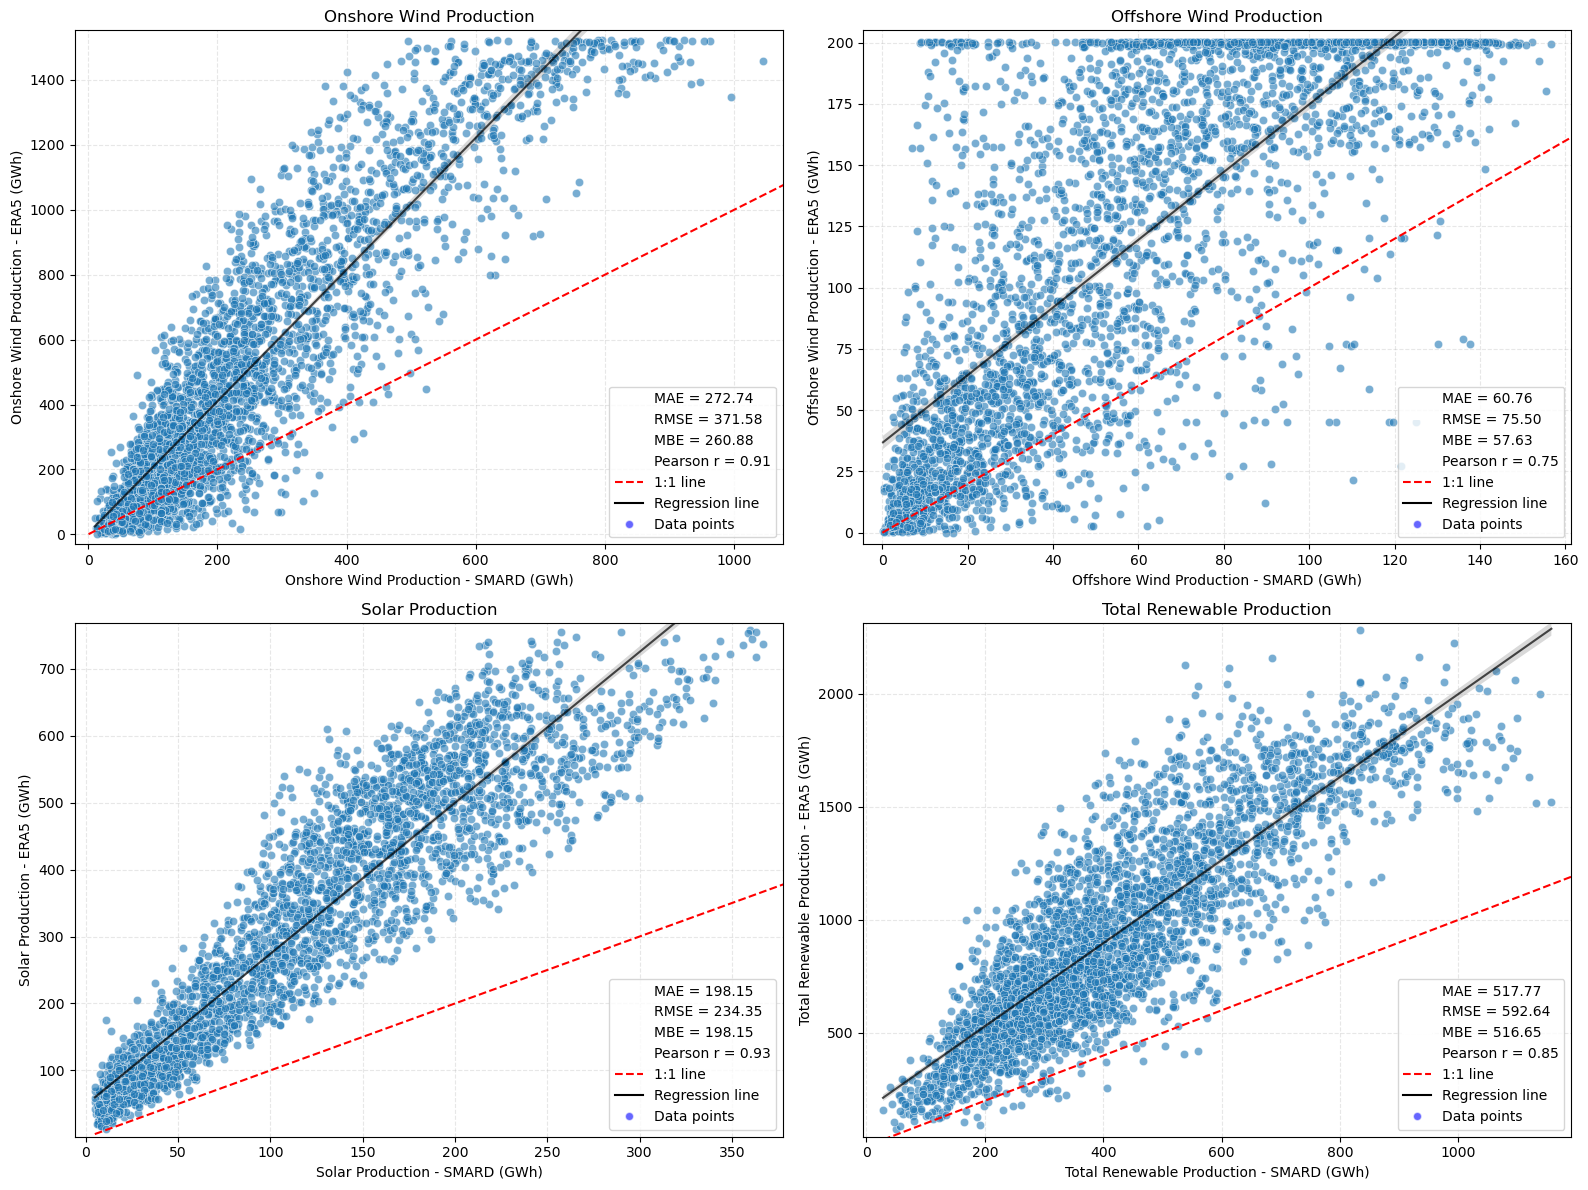

In [226]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plot_specs = [
    ('wind_onshore_SMARD', 'wind_onshore_ERA5', 'Onshore Wind Production'),
    ('wind_offshore_SMARD', 'wind_offshore_ERA5', 'Offshore Wind Production'),
    ('solar_SMARD', 'solar_ERA5', 'Solar Production'),
    ('total_production_SMARD', 'total_production_ERA5', 'Total Renewable Production')
]

for ax, (col_smard, col_era5, title) in zip(axs.flat, plot_specs):
    sns.scatterplot(x=col_smard, y=col_era5, data=df, alpha=0.6, ax=ax)
    
    # Regression line
    sns.regplot(x=col_smard, y=col_era5, data=df, scatter=False, color='black', line_kws={'linewidth': 1.5, 'alpha': 0.7}, ax=ax)
    
    xrange = df[col_smard].max() - df[col_smard].min()
    yrange = df[col_era5].max() - df[col_era5].min()
    
    ax.set_xlim(df[col_smard].min() - xrange * 0.03, df[col_smard].max() + xrange * 0.03)
    ax.set_ylim(df[col_era5].min() - xrange * 0.03, df[col_era5].max() + xrange * 0.03)
    
    # 1:1 line
    min_val = min(df[col_smard].min(), df[col_era5].min())
    max_val = max(df[col_smard].max(), df[col_era5].max())
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 line')

    # Pearson r
    r, _ = pearsonr(df[col_smard], df[col_era5])
    
    mae = np.mean(np.abs(df[col_smard] - df[col_era5]))
    rmse = np.sqrt(np.mean((df[col_smard] - df[col_era5])**2))
    mbe = np.mean(df[col_era5] - df[col_smard])


        # Custom legend entries
    legend_elements = [
        Line2D([0], [0], color='w', label=f'MAE = {mae:.2f}'),
        Line2D([0], [0], color='w', label=f'RMSE = {rmse:.2f}'),
        Line2D([0], [0], color='w', label=f'MBE = {mbe:.2f}'),
        Line2D([0], [0], color='w', label=f'Pearson r = {r:.2f}'),  # invisible line, just for text
        Line2D([0], [0], linestyle='--', color='red', label='1:1 line'),
        Line2D([0], [0], linestyle='-', color='black', label='Regression line'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Data points', alpha=0.6)
    ]
    ax.legend(handles=legend_elements, loc='lower right', frameon=True)
    ax.set_xlabel(f'{title} - SMARD (GWh)')
    ax.set_ylabel(f'{title} - ERA5 (GWh)')
    ax.set_title(f'{title}')
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.legend(loc='best')

plt.tight_layout()
plt.show()


### Demand

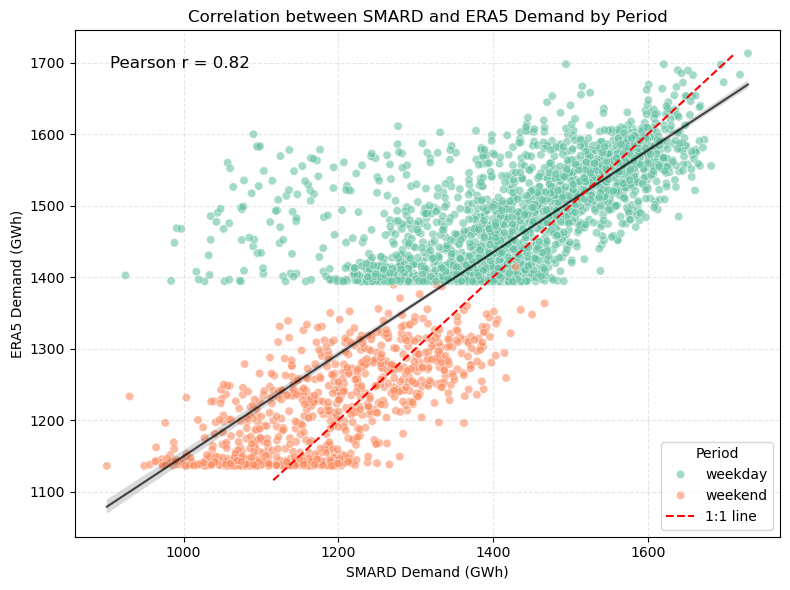

In [141]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='demand_SMARD', y='demand_ERA5', hue='period',  data=df, alpha=0.6, palette='Set2')

# Optional regression line (overall trend)
sns.regplot(x='demand_SMARD', y='demand_ERA5', data=df, scatter=False, color='black', line_kws={'linewidth': 1.5, 'alpha': 0.7})

# Pearson correlation
r, _ = pearsonr(df['demand_SMARD'], df['demand_ERA5'])
plt.text(0.05, 0.95, f'Pearson r = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# Plot 1:1 line
x = np.linspace(df['demand_ERA5'].min()-20, df['demand_ERA5'].max(), 100)
y = x
plt.plot(x, y, color='red', linestyle='--', label='1:1 line')


plt.xlabel('SMARD Demand (GWh)')
plt.ylabel('ERA5 Demand (GWh)')
plt.title('Correlation between SMARD and ERA5 Demand by Period')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Period', loc='best')
plt.tight_layout()
plt.show()


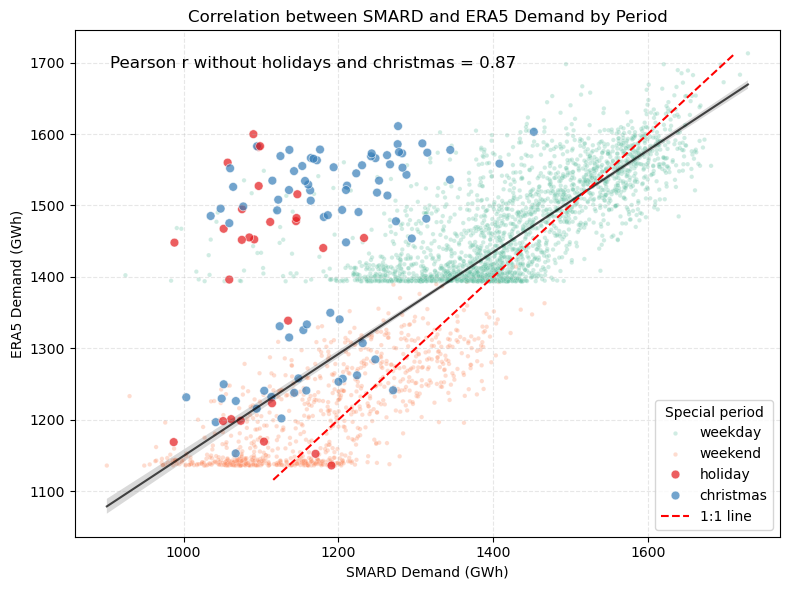

In [192]:
plt.figure(figsize=(8, 6))

# Background points: weekday & weekend
background_mask = df['special'].isin(['weekday', 'weekend', 'summer'])
sns.scatterplot(x='demand_SMARD', y='demand_ERA5', hue='period', data=df[background_mask], palette='Set2', alpha=0.3, s=10)

# Foreground points: special periods
foreground_mask = ~background_mask
sns.scatterplot(x='demand_SMARD', y='demand_ERA5', hue='special', data=df[foreground_mask], alpha=0.7, palette='Set1', s=40)

# Optional regression line
sns.regplot(x='demand_SMARD', y='demand_ERA5', data=df, scatter=False, color='black', line_kws={'linewidth': 1.5, 'alpha': 0.7})

# Pearson correlation
r, _ = pearsonr(df['demand_SMARD'], df['demand_ERA5'])
r, _ = pearsonr(df['demand_SMARD'][background_mask], df['demand_ERA5'][background_mask])

plt.text(0.05, 0.95, f'Pearson r without holidays and christmas = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# 1:1 line
x = np.linspace(df['demand_ERA5'].min() - 20, df['demand_ERA5'].max(), 100)
plt.plot(x, x, color='red', linestyle='--', label='1:1 line')

# Labels and styling
plt.xlabel('SMARD Demand (GWh)')
plt.ylabel('ERA5 Demand (GWh)')
plt.title('Correlation between SMARD and ERA5 Demand by Period')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Special period', loc='best')
plt.tight_layout()
plt.show()


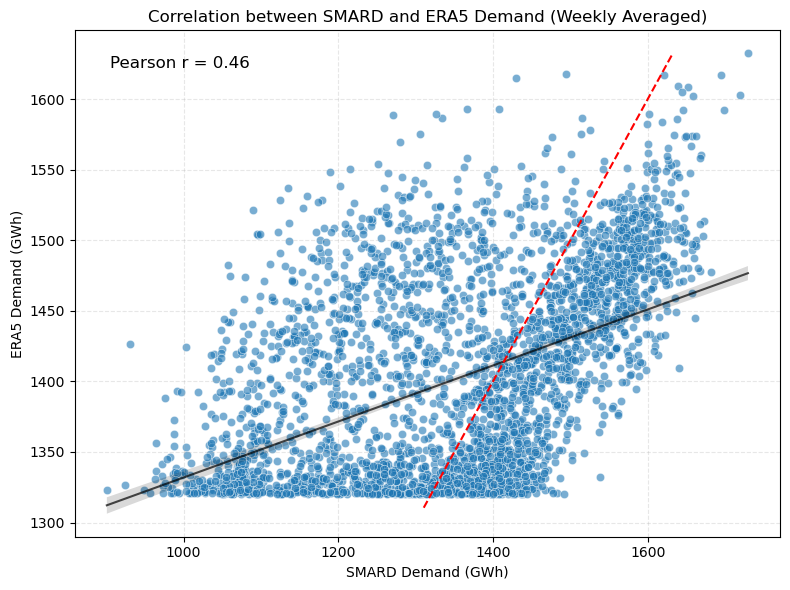

In [200]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='demand_SMARD', y='demand_ERA5_weekly',  data=df, alpha=0.6)

# Optional regression line (overall trend)
sns.regplot(x='demand_SMARD', y='demand_ERA5_weekly', data=df, scatter=False, color='black', line_kws={'linewidth': 1.5, 'alpha': 0.7})

# Pearson correlation
r, _ = pearsonr(df['demand_SMARD'], df['demand_ERA5_weekly'])
plt.text(0.05, 0.95, f'Pearson r = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# Plot 1:1 line
x = np.linspace(df['demand_ERA5_weekly'].min()-10, df['demand_ERA5_weekly'].max(), 100)
y = x
plt.plot(x, y, color='red', linestyle='--', label='1:1 line')

plt.xlabel('SMARD Demand (GWh)')
plt.ylabel('ERA5 Demand (GWh)')
# plt.xlim(900, 1800)
# plt.ylim(900, 1800)
plt.title('Correlation between SMARD and ERA5 Demand (Weekly Averaged)')
plt.grid(True, linestyle='--', alpha=0.3)
# plt.legend(title='Period', loc='best')
plt.tight_layout()
plt.show()


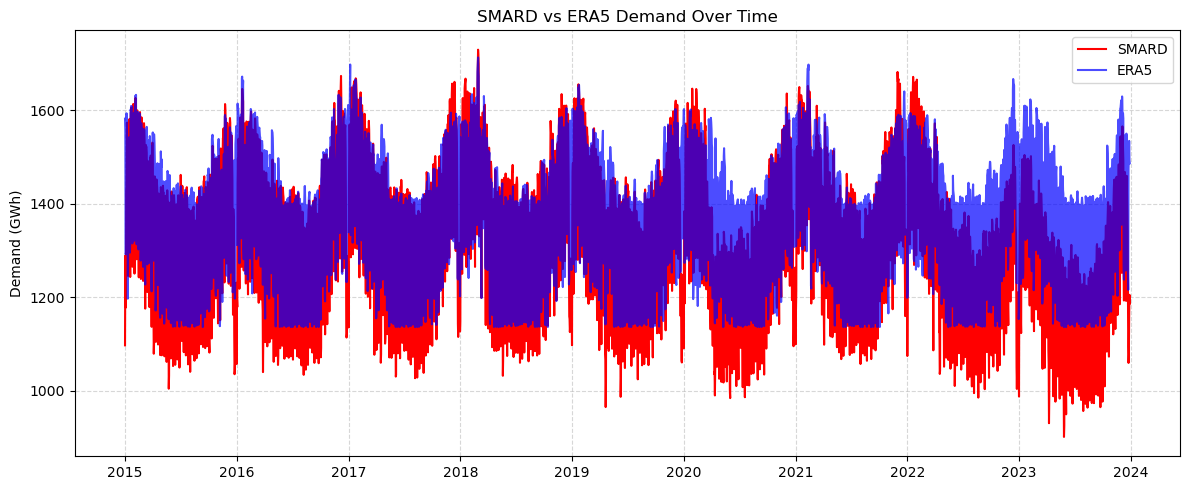

In [210]:
timestep1 = 0 #+ 365 * 8
timestep2 = 365 * 9

plt.figure(figsize=(12, 5))
plt.plot(df['date'][timestep1:timestep2], df['demand_SMARD'][timestep1:timestep2], label='SMARD', color='red')
plt.plot(df['date'][timestep1:timestep2], df['demand_ERA5'][timestep1:timestep2], label='ERA5', color='blue', alpha=0.7)
plt.title('SMARD vs ERA5 Demand Over Time')
plt.ylabel('Demand (GWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [147]:

demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')
# Create array from -15:45
temperature_plt = np.arange(-20, 60.5, 0.5)
v_weekday = demand_fit_values.sel(country = 9, period = 'weekday')
v_weekend = demand_fit_values.sel(country = 9, period = 'weekend')
v_week = demand_fit_values.sel(country = 9, period = 'week')

demand_weekday = np.zeros(len(temperature_plt))
demand_weekend = np.zeros(len(temperature_plt))
demand_week = np.zeros(len(temperature_plt))

for i in range(len(temperature_plt)):
    demand_weekday[i] = demand.LSTRmodel(temperature_plt[i], v_weekday)
    if (demand_weekday[i] > v_weekday.heating_max) & (temperature_plt[i] < v_weekday.f):
        demand_weekday[i] = v_weekday.heating_max
    if (demand_weekday[i] > v_weekday.cooling_max) & (temperature_plt[i] > v_weekday.f):
        demand_weekday[i] = v_weekday.cooling_max

    demand_weekend[i] = demand.LSTRmodel(temperature_plt[i], v_weekend)
    if (demand_weekend[i] > v_weekend.heating_max) & (temperature_plt[i] < v_weekend.f):
        demand_weekend[i] = v_weekend.heating_max
    if (demand_weekend[i] > v_weekend.cooling_max) & (temperature_plt[i] > v_weekend.f):
        demand_weekend[i] = v_weekend.cooling_max
    
    demand_week[i] = demand.LSTRmodel(temperature_plt[i], v_week)
    if (demand_week[i] > v_week.heating_max) & (temperature_plt[i] < v_week.f):
        demand_week[i] = v_week.heating_max
    if (demand_week[i] > v_week.cooling_max) & (temperature_plt[i] > v_week.f):
        demand_week[i] = v_week.cooling_max

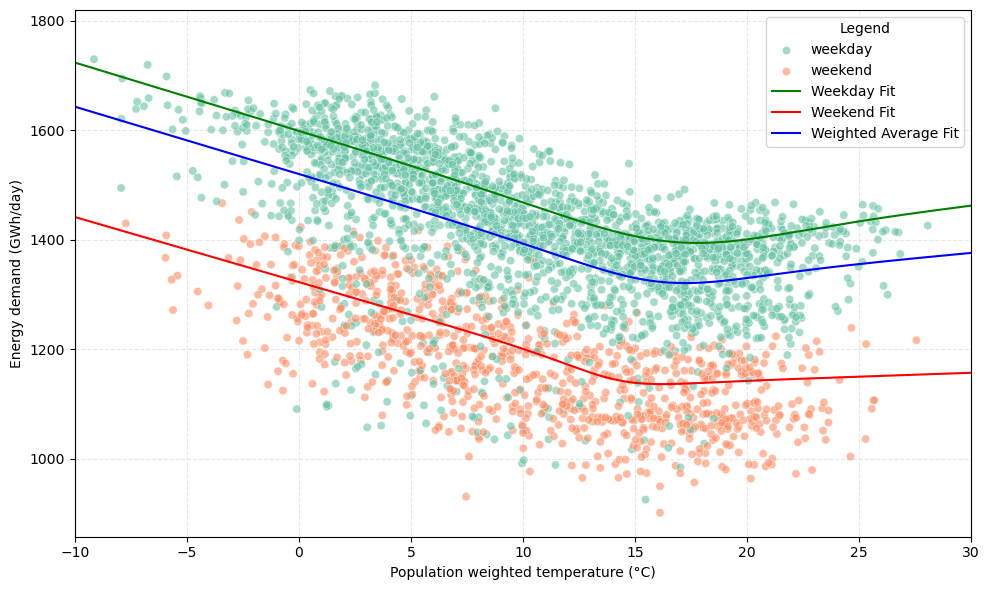

In [150]:
plt.figure(figsize=(10, 6))

# Scatterplot
scatter = sns.scatterplot(x='temp_ERA5', y='demand_SMARD', hue='period', data=df, alpha=0.6, palette='Set2')

# Line plots
line1 = plt.plot(temperature_plt, demand_weekday, linestyle='-', color='g', label='Weekday Fit')
line2 = plt.plot(temperature_plt, demand_weekend, linestyle='-', color='r', label='Weekend Fit')
line3 = plt.plot(temperature_plt, demand_week, linestyle='-', color='b', label='Weighted Average Fit')

# Get handles and labels from scatter
scatter_handles, scatter_labels = scatter.get_legend_handles_labels()

plt.legend(handles=scatter_handles, labels=scatter_labels, title='Legend', loc='best')

# Final touches
plt.ylabel('Energy demand (GWh/day)')
plt.xlabel('Population weighted temperature (°C)')
# plt.title('Energy Demand and ERA5 Temperature Data 2015–2023')
plt.xlim([-10, 30])
# plt.xlim([-20, 60])

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# save the plot
plt.savefig('/home/onennecke/Code/Figures/demand_fit_germany_draft.png', dpi=300, bbox_inches='tight')

plt.show()
